In [1]:
### what would chatgpt do?

# asking chatgpt what to do. https://chatgpt.com/c/69039ee9-ac90-8330-8797-7163fe276e98

# Environment
## Load packages
import glob, os
import skimage
from skimage import img_as_float, filters, morphology, feature, measure, segmentation, io, util
from skimage.morphology import skeletonize, disk
from skimage.segmentation import mark_boundaries
from scipy.ndimage import convolve
import scipy
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import napari_segment_blobs_and_things_with_membranes as nsbatwm
import napari_simpleitk_image_processing as nsitk


## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

DATA_DIR = DIR / "input_data" / "BBBC006_v1_images_z_16"

In [2]:
def show_overlay(image, label_mask, title=""):
    plt.figure(figsize=(5,5))
    plt.imshow(mark_boundaries(image, label_mask))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [3]:
# # let's have a look
# 2. List files
files = sorted(DATA_DIR.glob("*_w1*.tif"))[ :14]
files

### for a list of tifs
images = [ ]
for file in files:
    images.append(skimage.io.imread(file))
# skimage.io.imread_collection(files)

print(images[0].shape)
print('we have ', len(images), ' images')
print('each image has ', images[0].shape, ' pixels')

(520, 696)
we have  14  images
each image has  (520, 696)  pixels


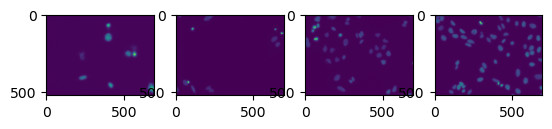

In [4]:
## Show a few images
fig, ax = plt.subplots(ncols = 4 )

ax[0].imshow(images[0])
ax[1].imshow(images[4])
ax[2].imshow(images[9])
ax[3].imshow(images[13])

In [5]:
img = images[7]

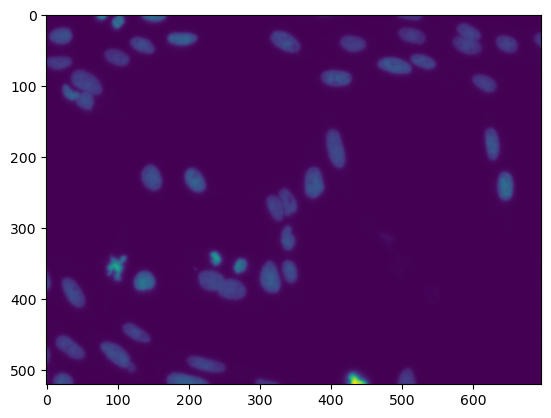

In [6]:
blur = filters.gaussian(img, sigma=1.2)
plt.imshow(blur)

In [7]:
# optional background estimate
### this was making some of the rounded cells weird shapes.
# bg = morphology.opening(blur, morphology.disk(15))
# norm = blur - bg

# plt.imshow(norm)

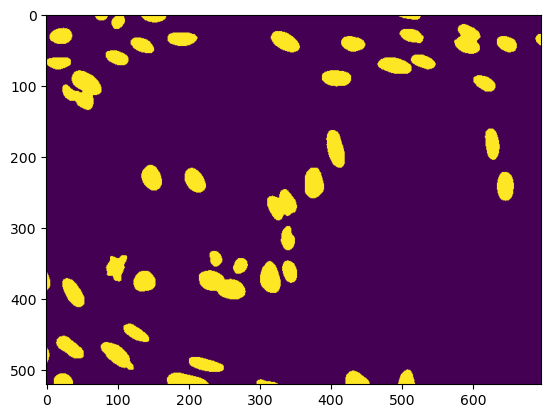

In [8]:
## threshold and clean
th = filters.threshold_otsu(blur)
bw = blur > th

bw = morphology.remove_small_objects(bw, min_size=50)
bw = morphology.remove_small_holes(bw, area_threshold=50)

plt.imshow(bw)

In [30]:
dist = ndi.distance_transform_edt(bw) # for each pixel, calculates shortest distance to background

# Estimate nucleus size
# find pixels that have high values relative to nearby pixels, targeting nucleus centre
rough_peaks = feature.peak_local_max(dist, labels=bw, min_distance=6)

# looking for median value of nuclei
r_med = np.median(dist[tuple(rough_peaks.T)]) if len(rough_peaks) else 6
# r_med = float(np.clip(r_med, 4, 15))
print(f"Estimated median radius: {r_med:.2f}")



Estimated median radius: 10.02


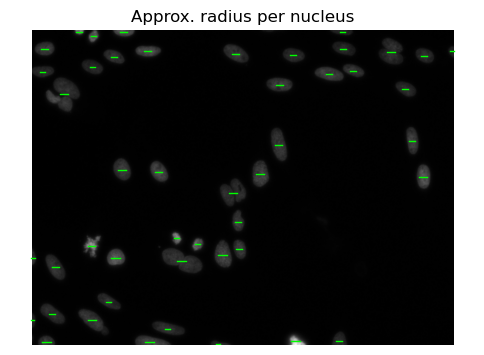

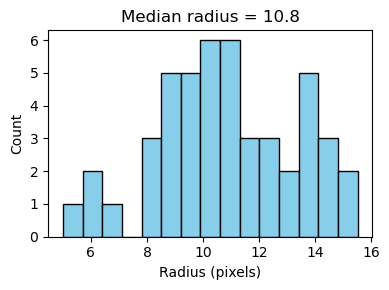

In [33]:
### Check radius estimates are reasonable

# --- Label connected components ---
labels_bw = measure.label(bw)

# --- For each nucleus, get centroid and max distance (radius) ---
radii = []
centroids = []

for region in measure.regionprops(labels_bw, intensity_image=dist):
    if region.area < 30:
        continue
    r_val = region.max_intensity
    cy, cx = region.weighted_centroid
    radii.append(r_val)
    centroids.append((cy, cx))

# --- Plot image with radius "ticks" ---
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Approx. radius per nucleus")

for (cy, cx), r in zip(centroids, radii):
    # small line along x-axis direction with length proportional to radius
    x0, x1 = cx - r/2, cx + r/2
    y0 = y1 = cy
    plt.plot([x0, x1], [y0, y1], '-', color='lime', lw=1)

plt.show()

# --- Optional: histogram of radius values ---
plt.figure(figsize=(4,3))
plt.hist(radii, bins=15, color='skyblue', edgecolor='k')
plt.xlabel("Radius (pixels)")
plt.ylabel("Count")
plt.title(f"Median radius = {np.median(radii):.1f}")
plt.tight_layout()
plt.show()


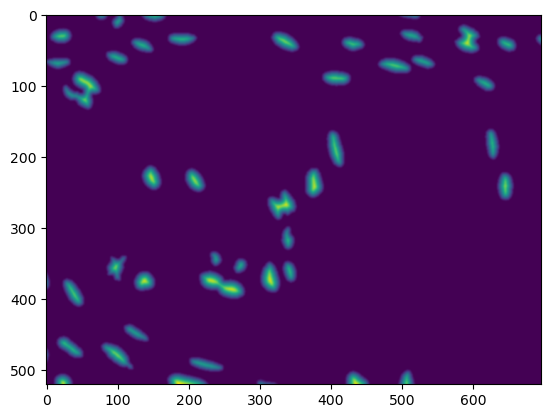

In [44]:
# --- Distance smoothing ---
dist_s = filters.gaussian(dist, sigma=0.1* r_med)

# --- Strong peaks (baseline) ---
h_strong = 0.4 * r_med
seeds_strong = morphology.h_maxima(dist_s, h_strong) & bw

# --- Weak peaks (to catch shallow doublets) ---
h_weak = 0.15 * r_med
seeds_weak = morphology.h_maxima(dist_s, h_weak) & bw


plt.imshow(dist_s)

In [56]:
# --- Guarantee at least one seed per object ---
labels_bw = measure.label(bw)
props = measure.regionprops(labels_bw)
for p in props:
    mask = labels_bw[p.slice] == p.label
    if np.sum(seeds_all[p.slice][mask]) == 0:
        # add seed at distance maximum
        local = dist_s[p.slice] * mask
        yy, xx = np.unravel_index(np.argmax(local), local.shape)
        seeds_all[p.slice][yy, xx] = True        

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(520, 696), dtype=int32)

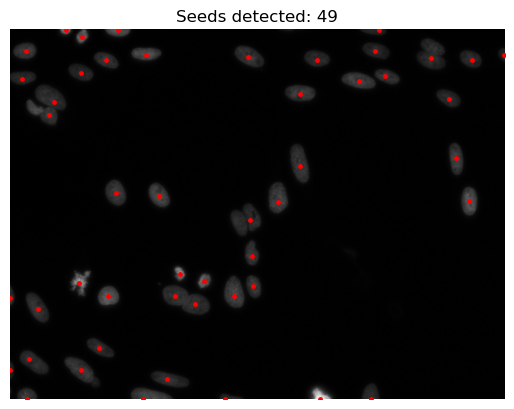

In [46]:


# Combine both, keep connected pixels reduced to single points
seeds_all = seeds_strong | seeds_weak
seeds_all = morphology.skeletonize(seeds_all)  # thin any small blobs
seeds_all = morphology.binary_dilation(seeds_all, morphology.disk(1)) & bw

# --- Guarantee at least one seed per object ---
labels_bw = measure.label(bw)
props = measure.regionprops(labels_bw)
for p in props:
    mask = labels_bw[p.slice] == p.label
    if np.sum(seeds_all[p.slice][mask]) == 0:
        # add seed at distance maximum
        local = dist_s[p.slice] * mask
        yy, xx = np.unravel_index(np.argmax(local), local.shape)
        seeds_all[p.slice][yy, xx] = True

# --- Reduce multiple close seeds within same nucleus ---
# (Keep seed with highest distance value)
labels_temp = measure.label(seeds_all)
filtered = np.zeros_like(seeds_all)
for region in measure.regionprops(labels_temp, intensity_image=dist_s):
    cy, cx = np.round(region.weighted_centroid).astype(int)
    filtered[cy, cx] = True
seeds_all = filtered & bw

# --- Marker image for watershed ---
coords = np.column_stack(np.nonzero(seeds_all))
markers = np.zeros_like(dist, int)
for i, (y, x) in enumerate(coords, start=1):
    markers[y, x] = i

# --- Visual check ---
plt.imshow(img, cmap='gray')
plt.scatter(coords[:,1], coords[:,0], c='red', s=6)
plt.title(f"Seeds detected: {len(coords)}")
plt.axis('off')
plt.show()


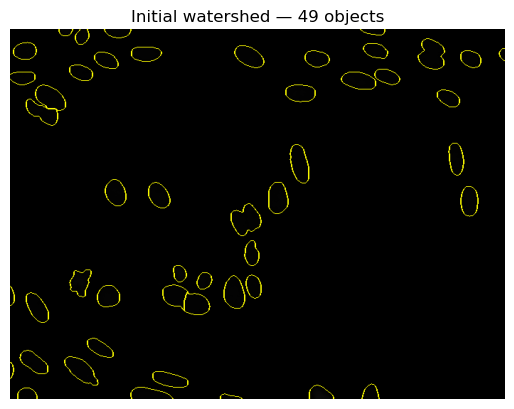

In [20]:
labels = segmentation.watershed(-dist_s, markers, mask=bw)
plt.imshow(segmentation.mark_boundaries(img, labels))
plt.title(f"Initial watershed — {labels.max()} objects")
plt.axis('off');

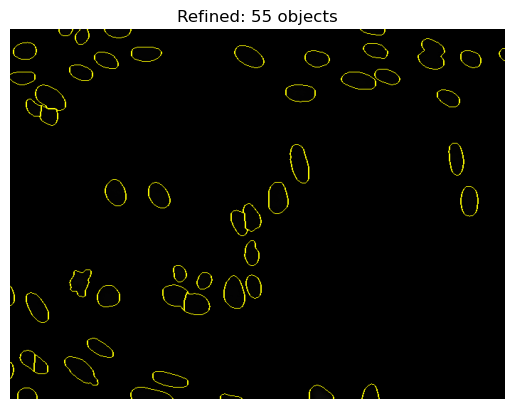

In [21]:
labels_refined = labels.copy()
props = measure.regionprops(labels)
area_thr = np.percentile([p.area for p in props], 90)
ecc_thr = 0.85

for p in props:
    if p.area < 50 or (p.area < area_thr and p.eccentricity < ecc_thr):
        continue
    mask = (labels == p.label)
    dist_local = ndi.distance_transform_edt(mask)
    dist_s_local = filters.gaussian(dist_local, sigma=1.0)
    peaks = feature.peak_local_max(dist_s_local, labels=mask, min_distance=int(0.7 * r_med))
    if len(peaks) < 2:
        continue

    markers_local = np.zeros_like(mask, dtype=int)
    for i, (y, x) in enumerate(peaks, start=1):
        markers_local[y, x] = i
    lab_local = segmentation.watershed(-dist_s_local, markers_local, mask=mask)

    # Replace with new labels
    labels_refined[mask] = 0
    for new_id in np.unique(lab_local)[1:]:
        labels_refined[lab_local == new_id] = labels_refined.max() + 1

plt.imshow(segmentation.mark_boundaries(img, labels_refined))
plt.title(f"Refined: {labels_refined.max()} objects")
plt.axis('off');

(np.float64(-0.5), np.float64(695.5), np.float64(519.5), np.float64(-0.5))

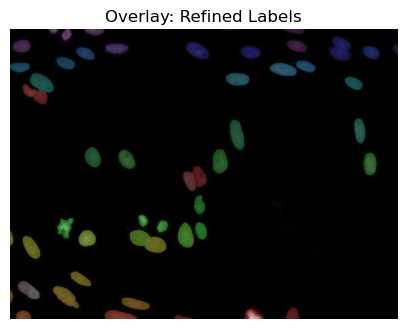

In [22]:
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray')
plt.imshow(labels_refined, cmap='nipy_spectral', alpha=0.3)
plt.title("Overlay: Refined Labels")
plt.axis("off")

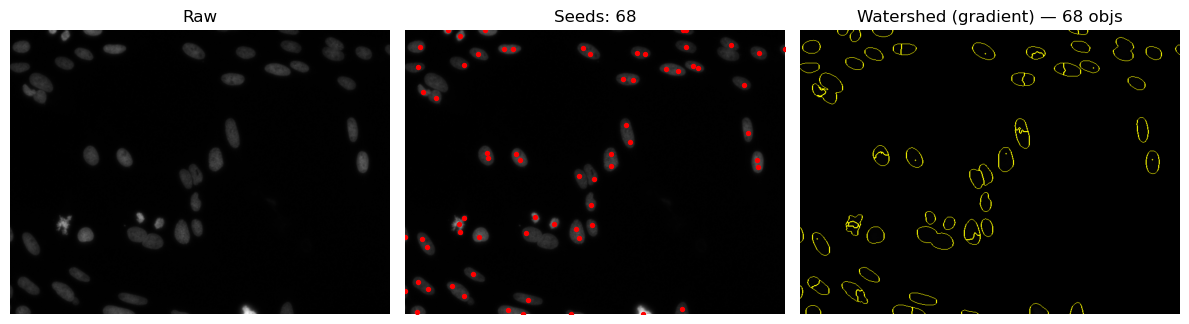

In [57]:
############# starting afresh ##############
from scipy.ndimage import gaussian_laplace
from skimage import exposure

# --- 0) Mild contrast normalization (robust; optional but helps) ---
imgn = exposure.rescale_intensity(blur, in_range='image')  # use your 'blur' image

# --- 1) Multi-scale Laplacian-of-Gaussian response (scale-normalized) ---
# Pick a sigma range that matches expected nuclear radii in pixels
# (adjust if needed: smaller if nuclei are tiny, larger if they are big)
sigmas = np.arange(2, 7, 1)  # 2..6 px
log_stack = np.stack([-(gaussian_laplace(imgn, s) * (s**2)) for s in sigmas], axis=-1)
log_resp  = log_stack.max(axis=-1)  # max over scales

# --- 2) Seed detection on LoG response (inside foreground only) ---
# Threshold adaptively and do non-maximum suppression
thr = np.percentile(log_resp[bw], 70)  # raise/lower 60–80 if too many/few seeds
coords = feature.peak_local_max(log_resp, labels=bw,
                                min_distance=4,      # adjust 3–7 as needed
                                threshold_abs=thr,
                                exclude_border=False)

# Guarantee at least one seed per connected component (no missed nuclei)
labels_bw = measure.label(bw)
seeds_mask = np.zeros_like(bw, bool)
seeds_mask[tuple(coords.T)] = True
for reg in measure.regionprops(labels_bw, intensity_image=log_resp):
    mask = (labels_bw == reg.label)
    if not np.any(seeds_mask & mask):
        # add the strongest LoG point in this object
        sl = reg.slice
        local = log_resp[sl] * mask[sl]
        if local.max() > 0:
            yy, xx = np.unravel_index(np.argmax(local), local.shape)
            seeds_mask[sl][yy, xx] = True

# Optional: de-duplicate very close seeds (keep strongest LoG)
lab_seeds = measure.label(seeds_mask)
filtered = np.zeros_like(seeds_mask)
for r in measure.regionprops(lab_seeds, intensity_image=log_resp):
    y, x = np.round(r.weighted_centroid).astype(int)
    filtered[y, x] = True
seeds_mask = filtered

# --- 3) Build marker image ---
markers = np.zeros_like(img, int)
yyx = np.column_stack(np.nonzero(seeds_mask))
for i, (y, x) in enumerate(yyx, start=1):
    markers[y, x] = i

# --- 4) Watershed on gradient magnitude (splits along edges between touching nuclei) ---
edges = filters.sobel(imgn)  # elevation map
labels = segmentation.watershed(edges, markers=markers, mask=bw)

# --- 5) Visualize seeds & result ---
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray'); plt.axis('off'); plt.title('Raw')

plt.subplot(1,3,2)
plt.imshow(img, cmap='gray'); plt.axis('off'); plt.title(f'Seeds: {len(yyx)}')
plt.scatter(yyx[:,1], yyx[:,0], s=8, c='r')

plt.subplot(1,3,3)
plt.imshow(segmentation.mark_boundaries(img, labels))
plt.axis('off'); plt.title(f'Watershed (gradient) — {labels.max()} objs')
plt.tight_layout(); plt.show()